<div style="background: linear-gradient(135deg, #1a0533, #0d1b6e); padding: 40px 30px; border-radius: 16px; text-align: center; font-family: 'Segoe UI', sans-serif;">
  <h1 style="color: #f0abfc; font-size: 2.4rem; margin-bottom: 8px;">🧠 Emotion Detection from Text</h1>
  <p style="color: #a78bfa; font-size: 1.1rem; margin-bottom: 20px;">An NLP pipeline to classify emotions in text using TF-IDF and Machine Learning</p>
  <hr style="border-color: rgba(167,139,250,0.3); margin: 16px 0;">
  <table style="margin: 0 auto; color: #c4b5fd; font-size: 0.9rem;">
    <tr><td style="padding: 4px 16px;"><b>👤 Author</b></td><td>kananiisha</td></tr>
    <tr><td style="padding: 4px 16px;"><b>📁 Dataset</b></td><td>train.txt / val.txt / test.txt</td></tr>
    <tr><td style="padding: 4px 16px;"><b>🤖 Model</b></td><td>LinearSVC (Calibrated) + TF-IDF</td></tr>
    <tr><td style="padding: 4px 16px;"><b>🏷️ Emotions</b></td><td>anger, fear, joy, love, sadness, surprise</td></tr>
  </table>
</div>

---
## 📋 Table of Contents

1. [Project Overview](#1-project-overview)
2. [Import Libraries](#2-import-libraries)
3. [Load Dataset](#3-load-dataset)
4. [Exploratory Data Analysis (EDA)](#4-exploratory-data-analysis)
5. [Text Preprocessing](#5-text-preprocessing)
6. [Feature Extraction (TF-IDF)](#6-feature-extraction)
7. [Model Training](#7-model-training)
8. [Model Evaluation](#8-model-evaluation)
9. [Prediction Function](#9-prediction-function)
10. [Test with Custom Input](#10-test-with-custom-input)

---

## 1. Project Overview

### 🎯 Goal
Automatically detect the **emotion** expressed in a piece of text — classifying it into one of: `anger`, `fear`, `joy`, `love`, `sadness`, or `surprise`.

### 🔄 Pipeline Summary

```
Raw Text → Preprocessing → TF-IDF Vectorization → LinearSVC → Emotion Label
```

### 📦 Steps We Follow

| Step | Description |
|------|-------------|
| **Data Loading** | Load train/val/test splits from `.txt` files |
| **EDA** | Explore class distribution, sample rows, dataset sizes |
| **Preprocessing** | Lowercase, remove punctuation, filter stopwords |
| **Feature Extraction** | TF-IDF with unigrams + bigrams |
| **Model Training** | LinearSVC wrapped in CalibratedClassifierCV |
| **Evaluation** | Accuracy, classification report, confusion matrix |
| **Inference** | Predict emotion + confidence on custom input |

---

## 2. Import Libraries

In [16]:
import pandas as pd
import numpy as np
import nltk
import string
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

nltk.download('stopwords', quiet=True)

# Plot styling
plt.rcParams.update({
    'figure.facecolor': '#0f0c29',
    'axes.facecolor': '#1a1040',
    'axes.edgecolor': '#7c3aed',
    'axes.labelcolor': '#c4b5fd',
    'xtick.color': '#c4b5fd',
    'ytick.color': '#c4b5fd',
    'text.color': '#f0abfc',
    'grid.color': '#2d1b69',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
})

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## 3. Load Dataset

The dataset is in semicolon-separated `.txt` format with two columns: `text` and `emotion`.

In [17]:
train_df = pd.read_csv("train.txt", sep=';', names=['text', 'emotion'])
test_df  = pd.read_csv("test.txt",  sep=';', names=['text', 'emotion'])
val_df   = pd.read_csv("val.txt",   sep=';', names=['text', 'emotion'])

print(f"📊 Train : {train_df.shape[0]:,} rows")
print(f"📊 Val   : {val_df.shape[0]:,} rows")
print(f"📊 Test  : {test_df.shape[0]:,} rows")
print()
train_df.head()

📊 Train : 16,000 rows
📊 Val   : 2,000 rows
📊 Test  : 2,000 rows



,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


## 4. Exploratory Data Analysis

In [18]:
# Class distribution
print("📌 Emotion distribution in training set:")
print(train_df['emotion'].value_counts())
print()

# Check for nulls
print("🔍 Missing values:")
print(train_df.isnull().sum())

📌 Emotion distribution in training set:
emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

🔍 Missing values:
text       0
emotion    0
dtype: int64


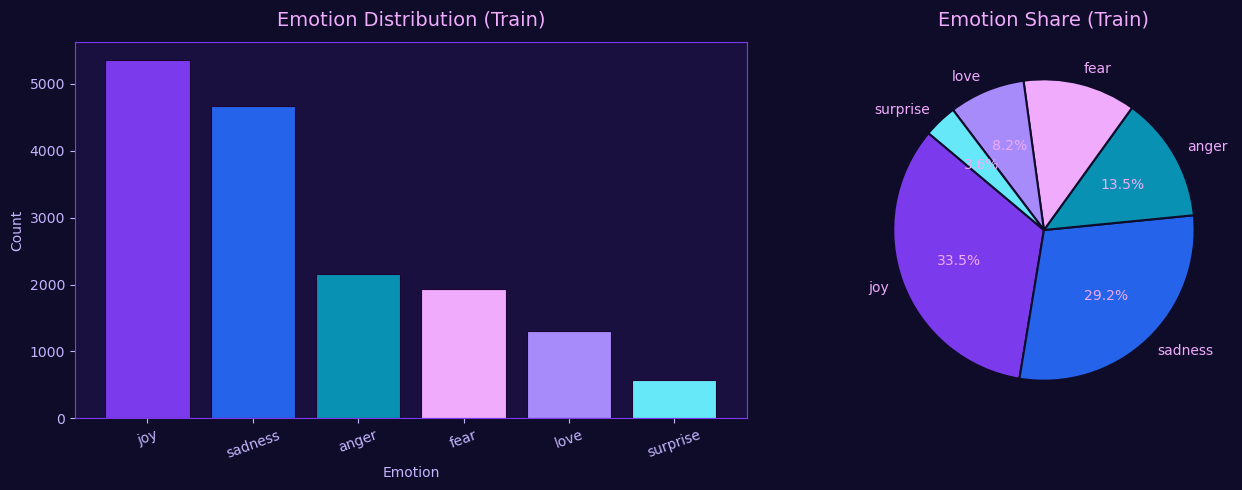

✅ Distribution plot saved.


In [19]:
# ── Plot 1: Emotion distribution bar chart ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0c29')

colors = ['#7c3aed', '#2563eb', '#0891b2', '#f0abfc', '#a78bfa', '#67e8f9']

# Bar chart
counts = train_df['emotion'].value_counts()
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='#1a0533', linewidth=0.8)
axes[0].set_title('Emotion Distribution (Train)', fontsize=14, pad=12)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

# Pie chart
axes[1].pie(
    counts.values,
    labels=counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': '#0f0c29', 'linewidth': 1.5}
)
axes[1].set_title('Emotion Share (Train)', fontsize=14, pad=12)

plt.tight_layout()
plt.savefig(r'C:/ISHA/Knowledge/Resume_Projects/Emotion Detection/screenshots/emotion_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f0c29')
plt.show()
print("✅ Distribution plot saved.")

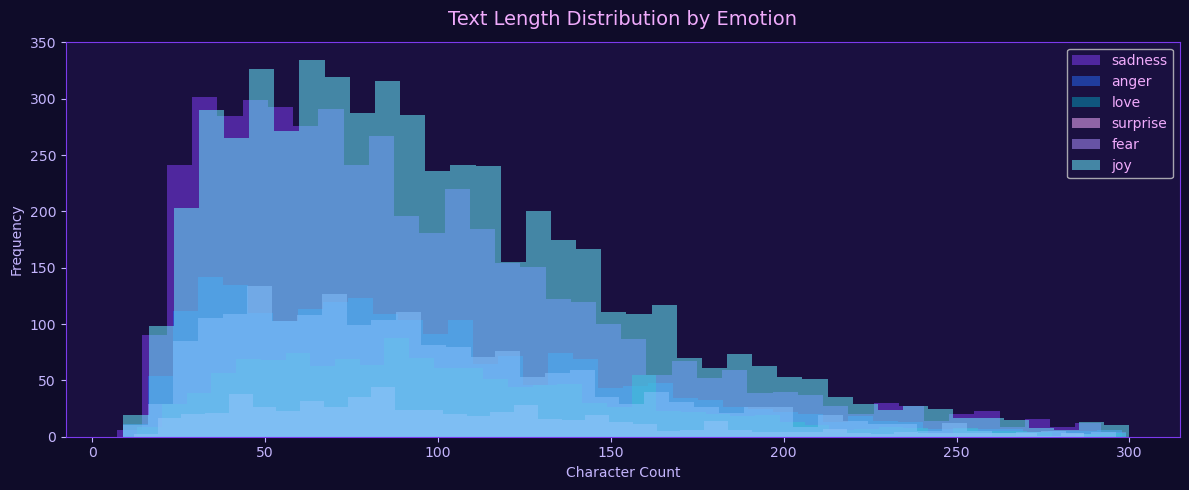

In [20]:
# ── Plot 2: Text length distribution by emotion ──────────────────────────────
train_df['text_len'] = train_df['text'].apply(len)

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0f0c29')

for i, emotion in enumerate(train_df['emotion'].unique()):
    subset = train_df[train_df['emotion'] == emotion]['text_len']
    ax.hist(subset, bins=40, alpha=0.55, label=emotion, color=colors[i % len(colors)])

ax.set_title('Text Length Distribution by Emotion', fontsize=14, pad=12)
ax.set_xlabel('Character Count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Text Preprocessing

We apply three cleaning steps:
1. **Lowercase** — normalise case
2. **Remove punctuation** — strip symbols
3. **Remove stopwords** — drop common words that carry no emotion signal (e.g. *the*, *is*, *a*)

In [21]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = "".join([char for char in text if char not in string.punctuation])
    words = text.split()
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

# Apply to all splits
train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text']  = test_df['text'].apply(clean_text)
val_df['clean_text']   = val_df['text'].apply(clean_text)

# Show before / after
print("BEFORE:", train_df['text'].iloc[0])
print("AFTER :", train_df['clean_text'].iloc[0])

BEFORE: i didnt feel humiliated
AFTER : didnt feel humiliated


## 6. Feature Extraction

We use **TF-IDF** (Term Frequency–Inverse Document Frequency) with **unigrams + bigrams** and a vocabulary cap of 50,000 features.

> Bigrams (e.g. *not happy*, *very scared*) capture negation and intensifiers that unigrams miss.

In [22]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=50000)

X_train = vectorizer.fit_transform(train_df['clean_text'])
X_val   = vectorizer.transform(val_df['clean_text'])
X_test  = vectorizer.transform(test_df['clean_text'])

y_train = train_df['emotion']
y_val   = val_df['emotion']
y_test  = test_df['emotion']

print(f"✅ Vocabulary size : {len(vectorizer.vocabulary_):,}")
print(f"✅ X_train shape   : {X_train.shape}")
print(f"✅ X_test shape    : {X_test.shape}")

✅ Vocabulary size : 50,000
✅ X_train shape   : (16000, 50000)
✅ X_test shape    : (2000, 50000)


## 7. Model Training

We use **LinearSVC** — a linear Support Vector Machine optimised for text classification.
It is wrapped in `CalibratedClassifierCV` to enable **probability / confidence** output.

> LinearSVC typically outperforms Logistic Regression on text tasks due to its hinge-loss margin optimisation.

In [23]:
base_model = LinearSVC(max_iter=2000, C=1.0)
model = CalibratedClassifierCV(base_model, cv=3)
model.fit(X_train, y_train)

print("✅ Model trained successfully.")

✅ Model trained successfully.


## 8. Model Evaluation

In [24]:
# ── Accuracy on val + test ───────────────────────────────────────────────────
val_preds  = model.predict(X_val)
test_preds = model.predict(X_test)

val_acc  = accuracy_score(y_val,  val_preds)
test_acc = accuracy_score(y_test, test_preds)

print(f"📈 Validation Accuracy : {val_acc:.4f}  ({val_acc*100:.2f}%)")
print(f"📈 Test Accuracy       : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print()
print("📋 Classification Report (Test Set):")
print(classification_report(y_test, test_preds))

📈 Validation Accuracy : 0.9100  (91.00%)
📈 Test Accuracy       : 0.8990  (89.90%)

📋 Classification Report (Test Set):
              precision    recall  f1-score   support

       anger       0.90      0.89      0.90       275
        fear       0.88      0.87      0.87       224
         joy       0.92      0.93      0.92       695
        love       0.76      0.81      0.78       159
     sadness       0.94      0.94      0.94       581
    surprise       0.74      0.65      0.69        66

    accuracy                           0.90      2000
   macro avg       0.86      0.85      0.85      2000
weighted avg       0.90      0.90      0.90      2000



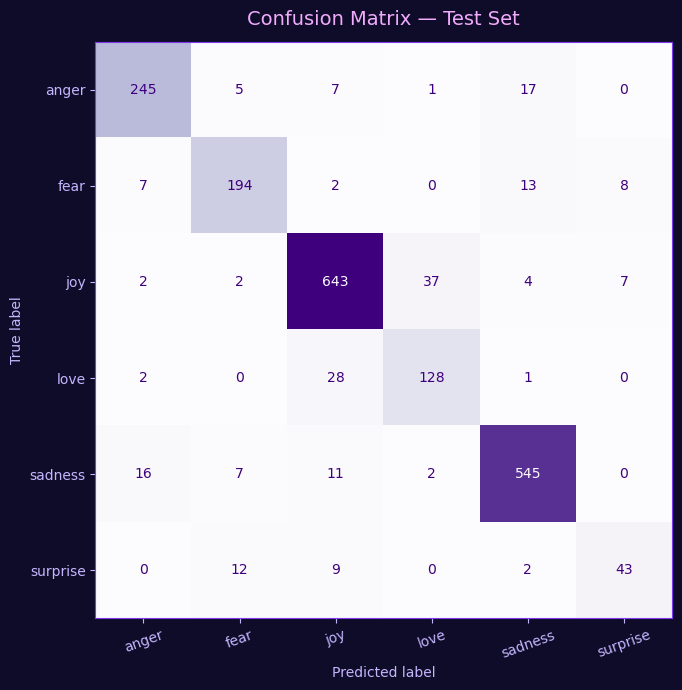

✅ Confusion matrix saved.


In [25]:
# ── Confusion matrix ─────────────────────────────────────────────────────────
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, test_preds, labels=labels)

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#0f0c29')
ax.set_facecolor('#1a1040')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(
    ax=ax,
    cmap='Purples',
    colorbar=False,
    xticks_rotation=20
)
ax.set_title('Confusion Matrix — Test Set', fontsize=14, pad=12, color='#f0abfc')
ax.tick_params(colors='#c4b5fd')
ax.xaxis.label.set_color('#c4b5fd')
ax.yaxis.label.set_color('#c4b5fd')

plt.tight_layout()
plt.savefig(r'C:/ISHA/Knowledge/Resume_Projects/Emotion Detection/screenshots/confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0f0c29')
plt.show()
print("✅ Confusion matrix saved.")

## 9. Prediction Function

In [26]:
def predict_emotion(text, show_confidence=True):
    """Predict the emotion of an input string."""
    cleaned = clean_text(text)
    if not cleaned:
        return "Unable to predict: empty after cleaning"
    
    vector = vectorizer.transform([cleaned])
    emotion = model.predict(vector)[0]
    
    if show_confidence:
        proba = model.predict_proba(vector)[0]
        classes = model.classes_
        conf_df = pd.DataFrame({
            'Emotion': classes,
            'Confidence': proba
        }).sort_values('Confidence', ascending=False)
        
        print(f"🎯 Predicted: {emotion.upper()}  ({max(proba)*100:.1f}% confidence)")
        print()
        print(conf_df.to_string(index=False))
        return emotion
    
    return emotion

## 10. Test with Custom Input

In [27]:
print("=" * 50)
print("Test 1:")
predict_emotion("I feel very happy today!")

Test 1:
🎯 Predicted: JOY  (98.7% confidence)

 Emotion  Confidence
     joy    0.987330
   anger    0.005287
    fear    0.002651
surprise    0.001872
 sadness    0.001579
    love    0.001281


'joy'

In [28]:
print("=" * 50)
print("Test 2:")
predict_emotion("I am so scared and terrified of the dark")

Test 2:
🎯 Predicted: FEAR  (99.5% confidence)

 Emotion   Confidence
    fear 9.954277e-01
    love 2.568661e-03
surprise 1.415643e-03
   anger 5.872894e-04
     joy 5.022591e-07
 sadness 1.899248e-07


'fear'

In [29]:
print("=" * 50)
print("Test 3:")
predict_emotion("This makes me so angry I could scream")

Test 3:
🎯 Predicted: ANGER  (96.5% confidence)

 Emotion  Confidence
   anger    0.964589
surprise    0.014373
    fear    0.013120
    love    0.004108
 sadness    0.002190
     joy    0.001620


'anger'

In [30]:
print("=" * 50)
print("Test 4:")
predict_emotion("I love you so much, you mean everything to me")

Test 4:
🎯 Predicted: JOY  (80.1% confidence)

 Emotion  Confidence
     joy    0.800977
    love    0.082074
   anger    0.064372
surprise    0.023151
    fear    0.016541
 sadness    0.012885


'joy'

---

<div style="background: linear-gradient(135deg, #1a0533, #0d1b6e); padding: 24px; border-radius: 12px; text-align: center; font-family: 'Segoe UI', sans-serif;">
  <p style="color: #a78bfa; font-size: 1rem; margin: 0;">
    🧠 <b style="color: #f0abfc;">Emotion Detection from Text</b> &nbsp;·&nbsp; 
    LinearSVC + TF-IDF &nbsp;·&nbsp;
    <a href="https://github.com/kananiisha/Emotion-Detection-from-Text" style="color: #67e8f9;">GitHub Repo</a>
  </p>
</div>